# KPI Analysis – Sales Trends

This notebook analyzes overall sales trends, including monthly order volume, total sales value, and average order value.

In [1]:
import pandas as pd
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

Python: 3.13.15 (main, Sep  1 2026, 14:16:48) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.5


In [2]:
from pathlib import Path

data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

In [3]:
from pathlib import Path
print(Path.cwd())

c:\Users\user777\Desktop\Conclusion Intelegence project\SpikupCapstone2026_CYRV\notebooks


In [4]:
data_path = Path("../data")

print("Data folder exists:", data_path.exists())

for item in data_path.iterdir():
    print(item.name)

Data folder exists: True
cyrv
README.md


In [5]:
data_path = Path("../data/cyrv")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

CYRV_customers_dataset.csv
CYRV_geolocation_dataset.csv
CYRV_orders_dataset.csv
CYRV_order_items_dataset.csv
CYRV_order_payments_dataset.csv
CYRV_order_reviews_dataset.csv
CYRV_products_dataset.csv
CYRV_sellers_dataset.csv
product_category_name_translation.csv


In [6]:
file_info = []

for file in csv_files:
    file_info.append({
        "file": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

pd.DataFrame(file_info).sort_values("size_mb", ascending=False)

,file,size_mb
1,CYRV_geolocation_dataset.csv,59.39
2,CYRV_orders_dataset.csv,16.93
3,CYRV_order_items_dataset.csv,14.83
5,CYRV_order_reviews_dataset.csv,13.78
0,CYRV_customers_dataset.csv,8.71
4,CYRV_order_payments_dataset.csv,5.61
6,CYRV_products_dataset.csv,2.30
7,CYRV_sellers_dataset.csv,0.17
8,product_category_name_translation.csv,0.00


In [7]:
customers = pd.read_csv(data_path / "CYRV_customers_dataset.csv")
orders = pd.read_csv(data_path / "CYRV_orders_dataset.csv")
order_items = pd.read_csv(data_path / "CYRV_order_items_dataset.csv")
payments = pd.read_csv(data_path / "CYRV_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "CYRV_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "CYRV_products_dataset.csv")
sellers = pd.read_csv(data_path / "CYRV_sellers_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [8]:
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [10]:
print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [11]:
monthly_orders = (
    orders
    .assign(month=orders["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("month")
    .size()
    .reset_index(name="number_of_orders")
)

monthly_orders

,month,number_of_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [12]:
orders[
    orders["order_purchase_timestamp"] >= "2018-08-01"
]["order_purchase_timestamp"].dt.date.value_counts().sort_index()

order_purchase_timestamp
2018-08-01    311
2018-08-02    302
2018-08-03    314
2018-08-04    245
2018-08-05    276
2018-08-06    372
2018-08-07    370
2018-08-08    316
2018-08-09    289
2018-08-10    256
2018-08-11    188
2018-08-12    197
2018-08-13    292
2018-08-14    316
2018-08-15    288
2018-08-16    320
2018-08-17    257
2018-08-18    198
2018-08-19    204
2018-08-20    256
2018-08-21    243
2018-08-22    187
2018-08-23    144
2018-08-24     99
2018-08-25     69
2018-08-26     73
2018-08-27     67
2018-08-28     44
2018-08-29     14
2018-08-30      4
2018-08-31      1
2018-09-03      4
2018-09-06      3
2018-09-10      1
2018-09-11      1
2018-09-12      1
2018-09-13      1
2018-09-17      1
2018-09-20      1
2018-09-25      1
2018-09-26      1
2018-09-29      1
2018-10-01      1
2018-10-03      1
2018-10-16      1
2018-10-17      1
Name: count, dtype: int64

In [13]:
orders_core = orders[
    (orders["order_purchase_timestamp"] >= "2017-01-01") &
    (orders["order_purchase_timestamp"] < "2018-09-01")
].copy()

print("Core analysis period:")
print(orders_core["order_purchase_timestamp"].min())
print("to")
print(orders_core["order_purchase_timestamp"].max())

print("\nOrders included:", len(orders_core))

Core analysis period:
2017-01-05 11:56:06
to
2018-08-31 16:13:44

Orders included: 99092


In [14]:
payment_per_order = (
    payments
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

orders_revenue = orders_core.merge(
    payment_per_order,
    on="order_id",
    how="left"
)

print("Orders:", len(orders_revenue))
print("Orders without payment:", orders_revenue["payment_value"].isna().sum())

Orders: 99092
Orders without payment: 0


In [15]:
orders_revenue["month"] = (
    orders_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_sales = (
    orders_revenue
    .groupby("month")
    .agg(
        number_of_orders=("order_id", "nunique"),
        gross_payment_value=("payment_value", "sum"),
        average_order_value=("payment_value", "mean")
    )
    .reset_index()
)

monthly_sales["gross_payment_value"] = (
    monthly_sales["gross_payment_value"].round(2)
)

monthly_sales["average_order_value"] = (
    monthly_sales["average_order_value"].round(2)
)

monthly_sales

,month,number_of_orders,gross_payment_value,average_order_value
0,2017-01,800,138488.04,173.11
1,2017-02,1780,291908.01,163.99
2,2017-03,2682,449863.60,167.73
3,2017-04,2404,417788.03,173.79
4,2017-05,3700,592918.82,160.25
5,2017-06,3245,511276.38,157.56
6,2017-07,4026,592382.92,147.14
7,2017-08,4331,674396.32,155.71
8,2017-09,4285,727762.45,169.84
9,2017-10,4631,779677.88,168.36


In [16]:
monthly_sales["order_growth_pct"] = (
    monthly_sales["number_of_orders"]
    .pct_change() * 100
).round(2)

monthly_sales["payment_growth_pct"] = (
    monthly_sales["gross_payment_value"]
    .pct_change() * 100
).round(2)

monthly_sales

,month,number_of_orders,gross_payment_value,average_order_value,order_growth_pct,payment_growth_pct
0,2017-01,800,138488.04,173.11,NaN,NaN
1,2017-02,1780,291908.01,163.99,122.50,110.78
2,2017-03,2682,449863.60,167.73,50.67,54.11
3,2017-04,2404,417788.03,173.79,-10.37,-7.13
4,2017-05,3700,592918.82,160.25,53.91,41.92
5,2017-06,3245,511276.38,157.56,-12.30,-13.77
6,2017-07,4026,592382.92,147.14,24.07,15.86
7,2017-08,4331,674396.32,155.71,7.58,13.84
8,2017-09,4285,727762.45,169.84,-1.06,7.91
9,2017-10,4631,779677.88,168.36,8.07,7.13


In [17]:
print("Top 5 months by number of orders:")
display(
    monthly_sales.nlargest(5, "number_of_orders")[
        ["month", "number_of_orders", "gross_payment_value", "average_order_value"]
    ]
)

print("\nTop 5 months by gross payment value:")
display(
    monthly_sales.nlargest(5, "gross_payment_value")[
        ["month", "number_of_orders", "gross_payment_value", "average_order_value"]
    ]
)

Top 5 months by number of orders:


,month,number_of_orders,gross_payment_value,average_order_value
10,2017-11,7544,1194882.80,158.39
12,2018-01,7269,1115004.18,153.39
14,2018-03,7211,1159652.12,160.82
15,2018-04,6939,1160785.48,167.28
16,2018-05,6873,1153982.15,167.90



Top 5 months by gross payment value:


,month,number_of_orders,gross_payment_value,average_order_value
10,2017-11,7544,1194882.80,158.39
15,2018-04,6939,1160785.48,167.28
14,2018-03,7211,1159652.12,160.82
16,2018-05,6873,1153982.15,167.90
12,2018-01,7269,1115004.18,153.39


## Initial Sales Trends Findings

- November 2017 recorded the highest order volume (7,544 orders) and the highest gross payment value (~1.19M).
- High sales months appear to be driven mainly by order volume rather than major changes in average order value.
- April 2018 generated slightly higher gross payment value than March 2018 despite having fewer orders, supported by a higher average order value.

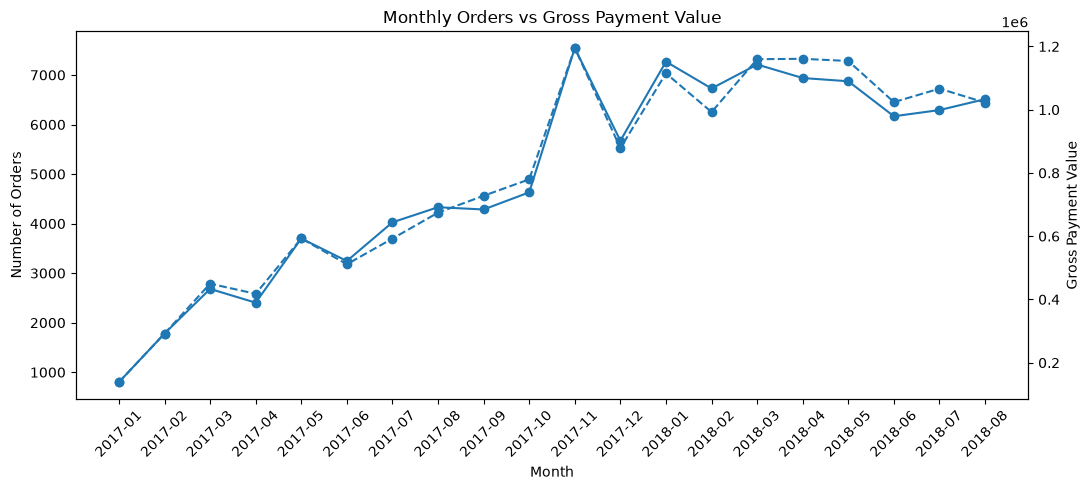

In [18]:
import matplotlib.pyplot as plt

months = monthly_sales["month"].astype(str)

fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    months,
    monthly_sales["number_of_orders"],
    marker="o",
    label="Number of Orders"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Number of Orders")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    months,
    monthly_sales["gross_payment_value"],
    marker="o",
    linestyle="--",
    label="Gross Payment Value"
)

ax2.set_ylabel("Gross Payment Value")

plt.title("Monthly Orders vs Gross Payment Value")
fig.tight_layout()
plt.show()

### Insight
- Order volume and gross payment value follow a very similar monthly pattern.
- November 2017 recorded the highest order volume with 7,544 orders and approximately 1.19M in gross payment value.
- This suggests that sales growth was mainly driven by higher order volume.

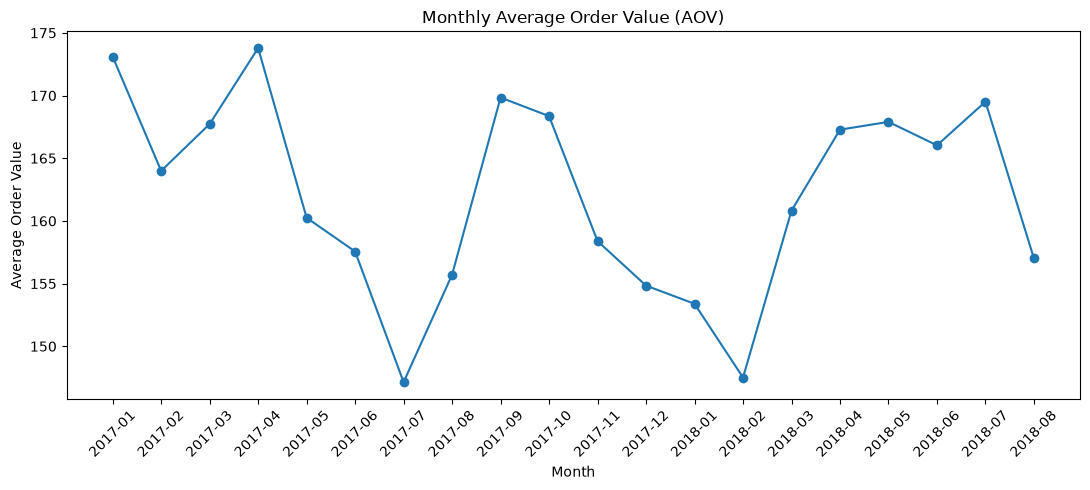

In [19]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_sales["month"].astype(str),
    monthly_sales["average_order_value"],
    marker="o"
)

plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight
- Average Order Value (AOV) remained relatively stable, fluctuating between approximately 147 and 173.
- There is no clear upward trend in AOV over the analysis period.
- Therefore, the growth in gross payment value was mainly driven by increasing order volume rather than higher spending per order.

### Business Recommendations

- Prepare inventory and logistics capacity in advance for high-demand months.
- Increase marketing campaigns before periods that historically show strong sales growth.
- Investigate months with significant sales declines to identify potential operational or demand-related issues.
- Use monthly sales and order trends to support forecasting, budgeting, and resource planning.